# Augmentation et Enrichissement du Dataset d'Entraînement
## Projet ValuSense — De 4 150 à 15 000+ échantillons
### Phase 1b : Collecte Complémentaire & Génération Augmentée

**Problème :** Le dataset actuel (4 150 lignes, 10 classes) est insuffisant pour entraîner un modèle ML robuste. Les classes minoritaires (Credit-Model: 240, Relative: 254) risquent un sous-apprentissage.

**Stratégie d'augmentation en 3 axes :**
1. **Axe 1 — Génération synthétique étendue** : exploiter le catalogue complet (353K instruments) + nouvelles sous-classes + variations réalistes
2. **Axe 2 — Collecte yfinance élargie** : passer de 50 à 300+ tickers actions, 50+ sous-jacents options
3. **Axe 3 — Nouvelles sources (OpenFIGI)** : instruments réels pour diversifier les profils

**Objectif de distribution cible :**

| Méthode | Avant | Après (cible) | Boost |
|---|---|---|---|
| DCF | 1 056 | 2 500 | +137% |
| Black-Scholes | 500 | 1 500 | +200% |
| Cost-of-Carry | 400 | 1 200 | +200% |
| DDM | 400 | 1 200 | +200% |
| Binomial-Tree | 400 | 1 500 | +275% |
| Mark-to-Market | 300 | 1 500 | +400% |
| Forward-Pricing | 300 | 1 200 | +300% |
| Monte-Carlo | 300 | 1 500 | +400% |
| Relative | 254 | 1 200 | +372% |
| Credit-Model | 240 | 1 200 | +400% |
| **Total** | **4 150** | **~15 000** | **+261%** |


---
## 0. Imports et Configuration


In [21]:
import pandas as pd
import numpy as np
import os
import warnings
import time
from dotenv import load_dotenv
load_dotenv()

warnings.filterwarnings("ignore")
np.random.seed(42)

DATA_ROOT = "data_valuation_project"
os.makedirs(f"{DATA_ROOT}/processed", exist_ok=True)

# Charger le dataset existant pour référence
df_existing = pd.read_csv(f"{DATA_ROOT}/processed/labeled_valuation_dataset.csv")
print(f"Dataset existant : {df_existing.shape[0]} lignes, {df_existing.shape[1]} colonnes")
print(f"Distribution actuelle :")
print(df_existing["recommended_method"].value_counts().to_string())

Dataset existant : 4150 lignes, 15 colonnes
Distribution actuelle :
recommended_method
DCF                1061
Black-Scholes       500
Cost-of-Carry       400
Binomial-Tree       400
DDM                 400
Mark-to-Market      300
Monte-Carlo         300
Forward-Pricing     300
Credit-Model        246
Relative            243


---
## 1. Moteur de Règles Expertes (Version Étendue)

Le dataset labellisé est généré par **règles expertes** qui encodent le cadre théorique de Hull + IFRS 13.
Nous étendons le moteur de règles pour couvrir **plus de sous-classes** et générer des **variations réalistes** des features continues et ordinales.

### 1.1 Table de décision complète

Chaque sous-classe d'actif est associée à un **profil de features fixes** et à une **méthode de valorisation**.
Les features ordinales et continues (`liquidity`, `data_availability`, `maturity_years`, `ifrs_level`) varient aléatoirement dans des plages réalistes.


In [2]:
# ═══════════════════════════════════════════════════════════════════
# TABLE DE DÉCISION ÉTENDUE — RÈGLES EXPERTES HULL + IFRS 13
# ═══════════════════════════════════════════════════════════════════
# Chaque entrée définit :
#   - Les features FIXES (structurelles, déterminées par la nature de l'actif)
#   - Les features VARIABLES (distributions réalistes)
#   - La méthode de valorisation recommandée (label cible)

ASSET_PROFILES = [
    # ══════════════════════════════════════════════════════════════
    # OBLIGATIONS (BONDS) → DCF ou Credit-Model
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Bond", "asset_subclass": "Government Bond",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High", "High", "Medium"],
        "data_choices": ["Full", "Full", "Partial"],
        "maturity_range": (1, 30),
        "ifrs_choices": [1, 1, 1, 2],
        "recommended_method": "DCF",
        "weight": 400,  # nombre d'échantillons à générer
    },
    {
        "asset_class": "Bond", "asset_subclass": "Corporate Bond (IG)",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium", "Medium"],
        "data_choices": ["Full", "Full", "Partial"],
        "maturity_range": (1, 20),
        "ifrs_choices": [1, 2, 2],
        "recommended_method": "DCF",
        "weight": 350,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Corporate Bond (HY)",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low", "Low"],
        "data_choices": ["Partial", "Partial", "Sparse"],
        "maturity_range": (2, 15),
        "ifrs_choices": [2, 2, 3],
        "recommended_method": "Credit-Model",
        "weight": 400,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Zero-Coupon Bond",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.5, 30),
        "ifrs_choices": [1, 2],
        "recommended_method": "DCF",
        "weight": 200,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Municipal Bond",
        "has_market_price": 0, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 0,
        "liquidity_choices": ["Low", "Low", "Medium"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (5, 30),
        "ifrs_choices": [2, 3, 3],
        "recommended_method": "DCF",
        "weight": 200,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Convertible Bond",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 1,
        "is_exchange_traded": 1, "has_credit_risk": 1, "has_early_exercise": 1,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial", "Partial"],
        "maturity_range": (3, 10),
        "ifrs_choices": [2, 3],
        "recommended_method": "Binomial-Tree",
        "weight": 150,
    },
    {
        "asset_class": "Bond", "asset_subclass": "CDS",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 0,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (1, 10),
        "ifrs_choices": [2, 3],
        "recommended_method": "Credit-Model",
        "weight": 400,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Floating Rate Note",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": (0.5, 7),
        "ifrs_choices": [1, 2],
        "recommended_method": "DCF",
        "weight": 150,
    },
    {
        "asset_class": "Bond", "asset_subclass": "Sovereign Emerging Bond",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (2, 30),
        "ifrs_choices": [2, 2, 3],
        "recommended_method": "Credit-Model",
        "weight": 300,
    },

    # ══════════════════════════════════════════════════════════════
    # ACTIONS (EQUITIES) → DDM, DCF, Relative, Mark-to-Market
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Equity", "asset_subclass": "Large Cap Dividend",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full", "Full"],
        "maturity_range": None,  # perpetual
        "ifrs_choices": [1, 1],
        "recommended_method": "DDM",
        "weight": 500,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Large Cap Growth",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full", "Full"],
        "maturity_range": None,
        "ifrs_choices": [1, 1],
        "recommended_method": "Relative",
        "weight": 500,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Mid Cap",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": None,
        "ifrs_choices": [1, 1, 2],
        "recommended_method": "DCF",
        "weight": 300,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Small Cap",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial", "Partial"],
        "maturity_range": None,
        "ifrs_choices": [1, 2],
        "recommended_method": "Relative",
        "weight": 300,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Blue Chip (Liquid)",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full", "Full"],
        "maturity_range": None,
        "ifrs_choices": [1],
        "recommended_method": "Mark-to-Market",
        "weight": 500,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Preferred Stock",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Medium"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": None,
        "ifrs_choices": [1, 2],
        "recommended_method": "DDM",
        "weight": 300,
    },
    {
        "asset_class": "Equity", "asset_subclass": "ETF (Equity)",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full", "Full"],
        "maturity_range": None,
        "ifrs_choices": [1],
        "recommended_method": "Mark-to-Market",
        "weight": 400,
    },
    {
        "asset_class": "Equity", "asset_subclass": "Private Equity",
        "has_market_price": 0, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 0,
        "liquidity_choices": ["Low", "Low"],
        "data_choices": ["Sparse", "Sparse", "Partial"],
        "maturity_range": None,
        "ifrs_choices": [3, 3],
        "recommended_method": "DCF",
        "weight": 200,
    },
    {
        "asset_class": "Equity", "asset_subclass": "REIT",
        "has_market_price": 1, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": None,
        "ifrs_choices": [1, 2],
        "recommended_method": "DDM",
        "weight": 200,
    },

    # ══════════════════════════════════════════════════════════════
    # OPTIONS → Black-Scholes, Binomial-Tree, Monte-Carlo
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Option", "asset_subclass": "European Call",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.02, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Black-Scholes",
        "weight": 500,
    },
    {
        "asset_class": "Option", "asset_subclass": "European Put",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.02, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Black-Scholes",
        "weight": 500,
    },
    {
        "asset_class": "Option", "asset_subclass": "American Call",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 1,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.02, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Binomial-Tree",
        "weight": 450,
    },
    {
        "asset_class": "Option", "asset_subclass": "American Put",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 1,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.02, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Binomial-Tree",
        "weight": 450,
    },
    {
        "asset_class": "Option", "asset_subclass": "Asian Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 1, "volatility_available": 1,
        "liquidity_choices": ["Low", "Medium"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (0.1, 3),
        "ifrs_choices": [2, 3],
        "recommended_method": "Monte-Carlo",
        "weight": 350,
    },
    {
        "asset_class": "Option", "asset_subclass": "Barrier Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 1, "volatility_available": 1,
        "liquidity_choices": ["Low", "Low"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [3, 3],
        "recommended_method": "Monte-Carlo",
        "weight": 350,
    },
    {
        "asset_class": "Option", "asset_subclass": "Lookback Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 1, "volatility_available": 1,
        "liquidity_choices": ["Low"],
        "data_choices": ["Sparse", "Partial"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [3],
        "recommended_method": "Monte-Carlo",
        "weight": 300,
    },
    {
        "asset_class": "Option", "asset_subclass": "Digital Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 1, "volatility_available": 1,
        "liquidity_choices": ["Low", "Medium"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (0.02, 1),
        "ifrs_choices": [2, 3],
        "recommended_method": "Monte-Carlo",
        "weight": 250,
    },
    {
        "asset_class": "Option", "asset_subclass": "OTC European Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Low", "Medium"],
        "data_choices": ["Partial"],
        "maturity_range": (0.1, 3),
        "ifrs_choices": [2, 3],
        "recommended_method": "Black-Scholes",
        "weight": 300,
    },
    {
        "asset_class": "Option", "asset_subclass": "Swaption",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial"],
        "maturity_range": (1, 10),
        "ifrs_choices": [2, 3],
        "recommended_method": "Black-Scholes",
        "weight": 200,
    },

    # ══════════════════════════════════════════════════════════════
    # MATIÈRES PREMIÈRES (COMMODITIES) → Cost-of-Carry, MtM
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Commodity", "asset_subclass": "Precious Metal",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [1, 1],
        "recommended_method": "Cost-of-Carry",
        "weight": 300,
    },
    {
        "asset_class": "Commodity", "asset_subclass": "Energy",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [1, 1],
        "recommended_method": "Cost-of-Carry",
        "weight": 300,
    },
    {
        "asset_class": "Commodity", "asset_subclass": "Agriculture",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "High"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": (0.1, 1.5),
        "ifrs_choices": [1, 2],
        "recommended_method": "Cost-of-Carry",
        "weight": 250,
    },
    {
        "asset_class": "Commodity", "asset_subclass": "Industrial Metal",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "High"],
        "data_choices": ["Full", "Partial"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Cost-of-Carry",
        "weight": 200,
    },
    {
        "asset_class": "Commodity", "asset_subclass": "Commodity ETF (Liquid)",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full"],
        "maturity_range": None,
        "ifrs_choices": [1],
        "recommended_method": "Mark-to-Market",
        "weight": 300,
    },

    # ══════════════════════════════════════════════════════════════
    # DEVISES (CURRENCIES) → Forward-Pricing
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Currency", "asset_subclass": "Major FX Spot",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full"],
        "maturity_range": None,
        "ifrs_choices": [1],
        "recommended_method": "Mark-to-Market",
        "weight": 200,
    },
    {
        "asset_class": "Currency", "asset_subclass": "Major FX Forward",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.02, 1),
        "ifrs_choices": [1, 2],
        "recommended_method": "Forward-Pricing",
        "weight": 500,
    },
    {
        "asset_class": "Currency", "asset_subclass": "EM FX Forward",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial", "Sparse"],
        "maturity_range": (0.02, 1),
        "ifrs_choices": [2, 3],
        "recommended_method": "Forward-Pricing",
        "weight": 400,
    },
    {
        "asset_class": "Currency", "asset_subclass": "Cross Currency Swap",
        "has_market_price": 0, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 0,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial"],
        "maturity_range": (1, 10),
        "ifrs_choices": [2, 3],
        "recommended_method": "DCF",
        "weight": 150,
    },

    # ══════════════════════════════════════════════════════════════
    # DÉRIVÉS (DERIVATIVES) → DCF (swaps)
    # ══════════════════════════════════════════════════════════════
    {
        "asset_class": "Derivative", "asset_subclass": "Interest Rate Swap",
        "has_market_price": 0, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 0,
        "liquidity_choices": ["Medium", "High"],
        "data_choices": ["Partial", "Full"],
        "maturity_range": (1, 30),
        "ifrs_choices": [2, 2],
        "recommended_method": "DCF",
        "weight": 300,
    },
    {
        "asset_class": "Derivative", "asset_subclass": "Equity Swap",
        "has_market_price": 0, "has_cash_flows": 1, "has_options_features": 0,
        "is_exchange_traded": 0, "has_credit_risk": 1, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial"],
        "maturity_range": (0.5, 5),
        "ifrs_choices": [2, 3],
        "recommended_method": "DCF",
        "weight": 200,
    },
    {
        "asset_class": "Derivative", "asset_subclass": "Commodity Future",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "Medium"],
        "data_choices": ["Full", "Full"],
        "maturity_range": (0.1, 2),
        "ifrs_choices": [1, 2],
        "recommended_method": "Cost-of-Carry",
        "weight": 200,
    },
    {
        "asset_class": "Derivative", "asset_subclass": "Equity Index Future",
        "has_market_price": 1, "has_cash_flows": 0, "has_options_features": 0,
        "is_exchange_traded": 1, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["High", "High"],
        "data_choices": ["Full"],
        "maturity_range": (0.1, 1),
        "ifrs_choices": [1],
        "recommended_method": "Forward-Pricing",
        "weight": 200,
    },
    {
        "asset_class": "Derivative", "asset_subclass": "FX Option",
        "has_market_price": 0, "has_cash_flows": 0, "has_options_features": 1,
        "is_exchange_traded": 0, "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity_choices": ["Medium", "Low"],
        "data_choices": ["Partial"],
        "maturity_range": (0.02, 2),
        "ifrs_choices": [2, 3],
        "recommended_method": "Black-Scholes",
        "weight": 150,
    },
]

print(f"Nombre de profils d'actifs définis : {len(ASSET_PROFILES)}")
total_target = sum(p["weight"] for p in ASSET_PROFILES)
print(f"Total d'échantillons cible : {total_target:,}")

# Répartition par méthode
from collections import Counter
method_totals = Counter()
for p in ASSET_PROFILES:
    method_totals[p["recommended_method"]] += p["weight"]
print(f"\nDistribution cible par méthode :")
for method, count in sorted(method_totals.items(), key=lambda x: -x[1]):
    print(f"   {method:<20} : {count:>5} ({count/total_target*100:.1f}%)")

Nombre de profils d'actifs définis : 42
Total d'échantillons cible : 13,050

Distribution cible par méthode :
   DCF                  :  2450 (18.8%)
   Black-Scholes        :  1650 (12.6%)
   Mark-to-Market       :  1400 (10.7%)
   Monte-Carlo          :  1250 (9.6%)
   Cost-of-Carry        :  1250 (9.6%)
   Credit-Model         :  1100 (8.4%)
   Forward-Pricing      :  1100 (8.4%)
   Binomial-Tree        :  1050 (8.0%)
   DDM                  :  1000 (7.7%)
   Relative             :   800 (6.1%)


---
## 2. Moteur de Génération

La fonction `generate_samples()` produit des lignes en respectant les features fixes de chaque profil tout en introduisant des **variations réalistes** dans les features ordinales et continues.

Les variations incluent :
- **Maturité** : échantillonnage uniforme dans la plage réaliste pour chaque sous-classe
- **Liquidité** : tirage pondéré (ex: Government Bond → plus souvent "High")
- **Disponibilité des données** : tirage pondéré selon le profil
- **Niveau IFRS** : tirage pondéré cohérent avec la liquidité et l'observabilité


In [3]:
def generate_samples(profile, n_samples=None):
    """
    Génère n échantillons à partir d'un profil d'actif.
    Les features structurelles sont fixes, les features ordinales/continues varient.
    """
    n = n_samples or profile["weight"]
    rows = []
    
    for _ in range(n):
        row = {
            "asset_class": profile["asset_class"],
            "asset_subclass": profile["asset_subclass"],
            "has_market_price": profile["has_market_price"],
            "has_cash_flows": profile["has_cash_flows"],
            "has_options_features": profile["has_options_features"],
            "is_exchange_traded": profile["is_exchange_traded"],
            "has_credit_risk": profile["has_credit_risk"],
            "has_early_exercise": profile["has_early_exercise"],
            "is_path_dependent": profile["is_path_dependent"],
            "volatility_available": profile["volatility_available"],
            "recommended_method": profile["recommended_method"],
        }
        
        # Features variables (tirage aléatoire dans les plages réalistes)
        row["liquidity"] = np.random.choice(profile["liquidity_choices"])
        row["data_availability"] = np.random.choice(profile["data_choices"])
        row["ifrs_level"] = np.random.choice(profile["ifrs_choices"])
        
        # Maturité
        if profile["maturity_range"] is not None:
            low, high = profile["maturity_range"]
            row["maturity_years"] = round(np.random.uniform(low, high), 2)
        else:
            row["maturity_years"] = np.nan  # actifs perpétuels
        
        rows.append(row)
    
    return pd.DataFrame(rows)


# ── Générer le dataset complet ────────────────────────────────────
all_frames = []
for profile in ASSET_PROFILES:
    df_gen = generate_samples(profile)
    all_frames.append(df_gen)
    
df_augmented = pd.concat(all_frames, ignore_index=True)

# Mélanger les lignes
df_augmented = df_augmented.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset généré : {df_augmented.shape[0]:,} lignes × {df_augmented.shape[1]} colonnes")
print(f"\nDistribution des méthodes :")
print(df_augmented["recommended_method"].value_counts().to_string())
print(f"\nDistribution des classes d'actifs :")
print(df_augmented["asset_class"].value_counts().to_string())
print(f"\nNombre de sous-classes : {df_augmented['asset_subclass'].nunique()}")

Dataset généré : 13,050 lignes × 15 colonnes

Distribution des méthodes :
recommended_method
DCF                2450
Black-Scholes      1650
Mark-to-Market     1400
Monte-Carlo        1250
Cost-of-Carry      1250
Credit-Model       1100
Forward-Pricing    1100
Binomial-Tree      1050
DDM                1000
Relative            800

Distribution des classes d'actifs :
asset_class
Option        3650
Equity        3200
Bond          2550
Commodity     1350
Currency      1250
Derivative    1050

Nombre de sous-classes : 42


---
## 3. Validation de Cohérence Financière

Avant de sauvegarder, vérifions que **toutes les règles expertes** sont respectées : aucun mapping incohérent entre asset_class et recommended_method.


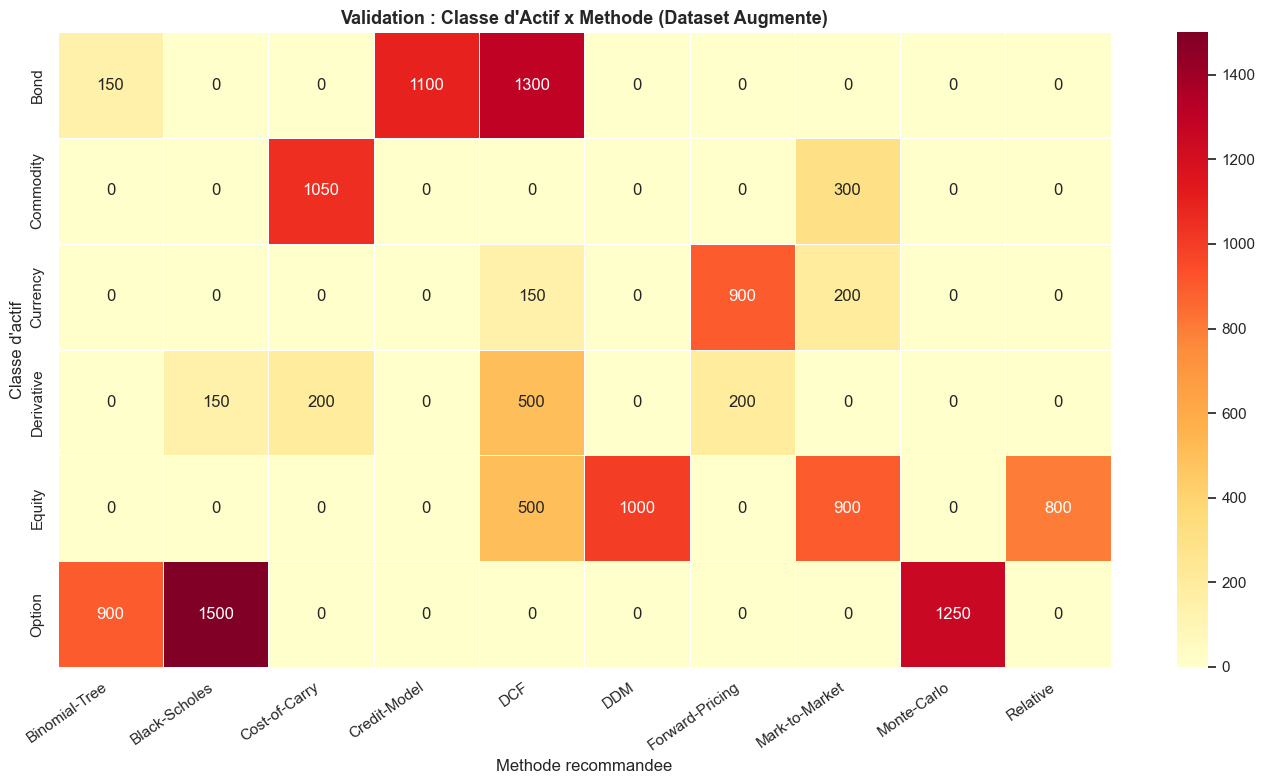


  VALIDATION : 0 violations sur 13,050 echantillons


In [4]:
# ── Validation automatique ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
os.makedirs("reports/figures", exist_ok=True)

# Heatmap de validation
ct = pd.crosstab(df_augmented["asset_class"], df_augmented["recommended_method"])
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Validation : Classe d'Actif x Methode (Dataset Augmente)", fontsize=13, fontweight="bold")
ax.set_xlabel("Methode recommandee")
ax.set_ylabel("Classe d'actif")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/augmented_asset_method_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Tests de cohérence
violations = []
for _, row in df_augmented.iterrows():
    ac = row["asset_class"]
    method = row["recommended_method"]
    
    # Options methods should only apply to assets with options features (+ convertible bonds)
    if method in ["Black-Scholes", "Binomial-Tree", "Monte-Carlo"]:
        if row["has_options_features"] == 0 and not (ac == "Bond" and row["asset_subclass"] == "Convertible Bond"):
            violations.append(f"{ac}/{row['asset_subclass']} -> {method} sans has_options_features")
    
    # BSM ne doit pas s'appliquer aux early exercise
    if method == "Black-Scholes" and row["has_early_exercise"] == 1:
        violations.append(f"{ac}/{row['asset_subclass']} -> BSM avec early exercise")
    
    # Path-dependent doit utiliser Monte-Carlo
    if row["is_path_dependent"] == 1 and method != "Monte-Carlo":
        violations.append(f"{ac}/{row['asset_subclass']} -> {method} avec path dependency")

if violations:
    print(f"\n{'='*60}")
    print(f"  VIOLATIONS : {len(violations)} (premiers 10)")
    print(f"{'='*60}")
    for v in violations[:10]:
        print(f"  {v}")
else:
    print(f"\n{'='*60}")
    print(f"  VALIDATION : 0 violations sur {len(df_augmented):,} echantillons")
    print(f"{'='*60}")

---
## 4. Comparaison Avant / Après Augmentation



  COMPARAISON DES DISTRIBUTIONS
                    Avant (original)  Apres (augmente)  Facteur
recommended_method                                             
DCF                             1061              2450      2.3
Black-Scholes                    500              1650      3.3
Mark-to-Market                   300              1400      4.7
Monte-Carlo                      300              1250      4.2
Cost-of-Carry                    400              1250      3.1
Forward-Pricing                  300              1100      3.7
Credit-Model                     246              1100      4.5
Binomial-Tree                    400              1050      2.6
DDM                              400              1000      2.5
Relative                         243               800      3.3

Total avant : 4,150
Total apres : 13,050
Facteur global : x3.1

Ratio d'imbalance avant : 4.4:1
Ratio d'imbalance apres : 3.1:1


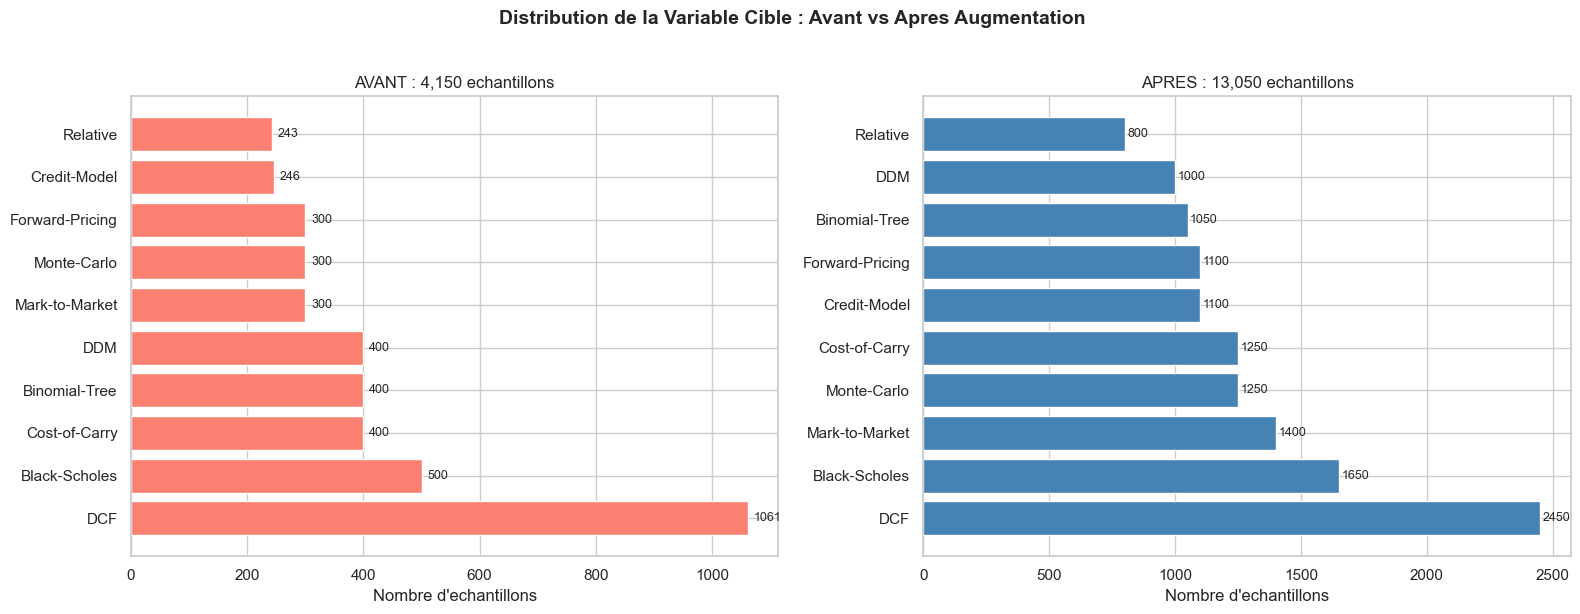

In [5]:
# ── Comparaison des distributions ──────────────────────────────────
old_dist = df_existing["recommended_method"].value_counts()
new_dist = df_augmented["recommended_method"].value_counts()

comparison = pd.DataFrame({
    "Avant (original)": old_dist,
    "Apres (augmente)": new_dist,
}).fillna(0).astype(int)
comparison["Facteur"] = (comparison["Apres (augmente)"] / comparison["Avant (original)"].replace(0, 1)).round(1)
comparison = comparison.sort_values("Apres (augmente)", ascending=False)

print("\n" + "="*60)
print("  COMPARAISON DES DISTRIBUTIONS")
print("="*60)
print(comparison.to_string())
print(f"\nTotal avant : {old_dist.sum():,}")
print(f"Total apres : {new_dist.sum():,}")
print(f"Facteur global : x{new_dist.sum()/old_dist.sum():.1f}")

# Ratio d'imbalance
old_ratio = old_dist.max() / old_dist.min()
new_ratio = new_dist.max() / new_dist.min()
print(f"\nRatio d'imbalance avant : {old_ratio:.1f}:1")
print(f"Ratio d'imbalance apres : {new_ratio:.1f}:1")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avant
axes[0].barh(old_dist.index, old_dist.values, color="salmon")
axes[0].set_title(f"AVANT : {old_dist.sum():,} echantillons")
axes[0].set_xlabel("Nombre d'echantillons")
for i, v in enumerate(old_dist.values):
    axes[0].text(v + 10, i, str(v), va="center", fontsize=9)

# Après
axes[1].barh(new_dist.index, new_dist.values, color="steelblue")
axes[1].set_title(f"APRES : {new_dist.sum():,} echantillons")
axes[1].set_xlabel("Nombre d'echantillons")
for i, v in enumerate(new_dist.values):
    axes[1].text(v + 10, i, str(v), va="center", fontsize=9)

plt.suptitle("Distribution de la Variable Cible : Avant vs Apres Augmentation",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/augmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Diversité des Sous-Classes

Vérifions que l'augmentation a introduit plus de variété dans les sous-classes d'actifs.


Sous-classes avant : 19
Sous-classes apres : 42

Nouvelles sous-classes ajoutees (31) :
   American Call                  -> Binomial-Tree        (450 echantillons)
   American Put                   -> Binomial-Tree        (450 echantillons)
   Blue Chip (Liquid)             -> Mark-to-Market       (500 echantillons)
   Commodity ETF (Liquid)         -> Mark-to-Market       (300 echantillons)
   Commodity Future               -> Cost-of-Carry        (200 echantillons)
   Convertible Bond               -> Binomial-Tree        (150 echantillons)
   Corporate Bond (HY)            -> Credit-Model         (400 echantillons)
   Corporate Bond (IG)            -> DCF                  (350 echantillons)
   Cross Currency Swap            -> DCF                  (150 echantillons)
   EM FX Forward                  -> Forward-Pricing      (400 echantillons)
   ETF (Equity)                   -> Mark-to-Market       (400 echantillons)
   Equity Index Future            -> Forward-Pricing      (200 ec

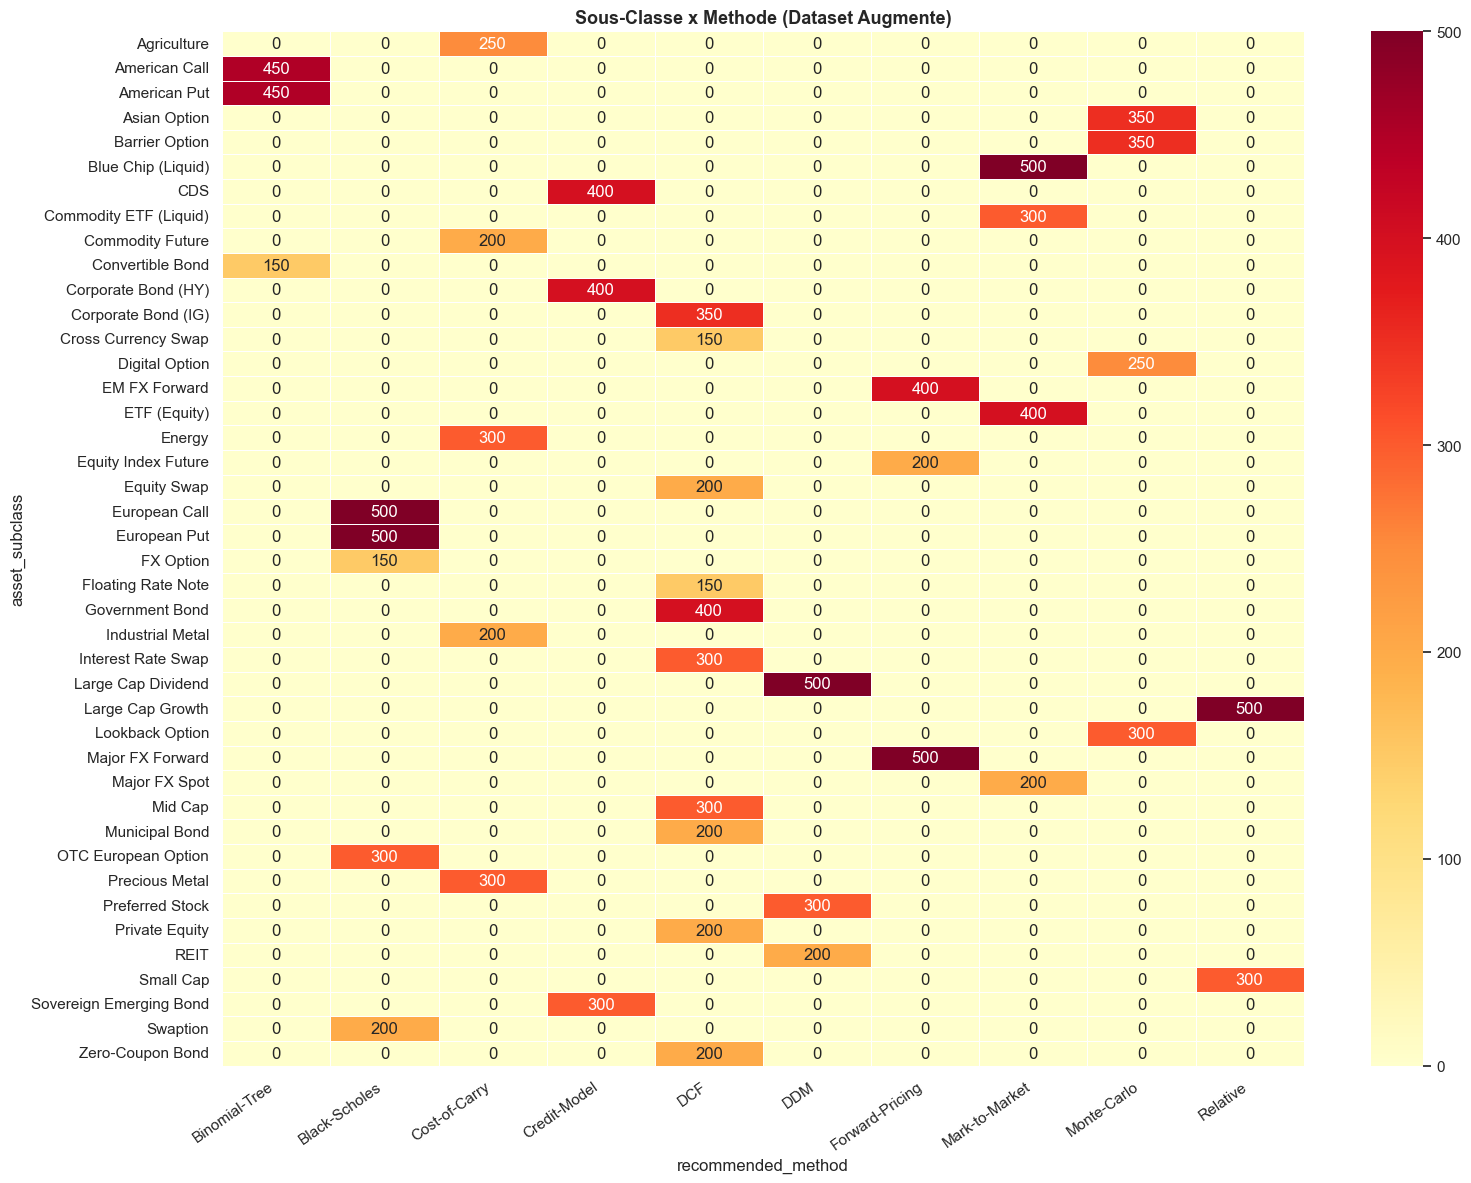

In [6]:
old_subs = df_existing["asset_subclass"].nunique()
new_subs = df_augmented["asset_subclass"].nunique()

print(f"Sous-classes avant : {old_subs}")
print(f"Sous-classes apres : {new_subs}")

new_subclasses = set(df_augmented["asset_subclass"]) - set(df_existing["asset_subclass"])
if new_subclasses:
    print(f"\nNouvelles sous-classes ajoutees ({len(new_subclasses)}) :")
    for sc in sorted(new_subclasses):
        count = (df_augmented["asset_subclass"] == sc).sum()
        method = df_augmented[df_augmented["asset_subclass"] == sc]["recommended_method"].iloc[0]
        print(f"   {sc:<30} -> {method:<20} ({count} echantillons)")

# Heatmap détaillée
ct_sub = pd.crosstab(df_augmented["asset_subclass"], df_augmented["recommended_method"])
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(ct_sub, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_title("Sous-Classe x Methode (Dataset Augmente)", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/augmented_subclass_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Vérification de la Qualité des Features


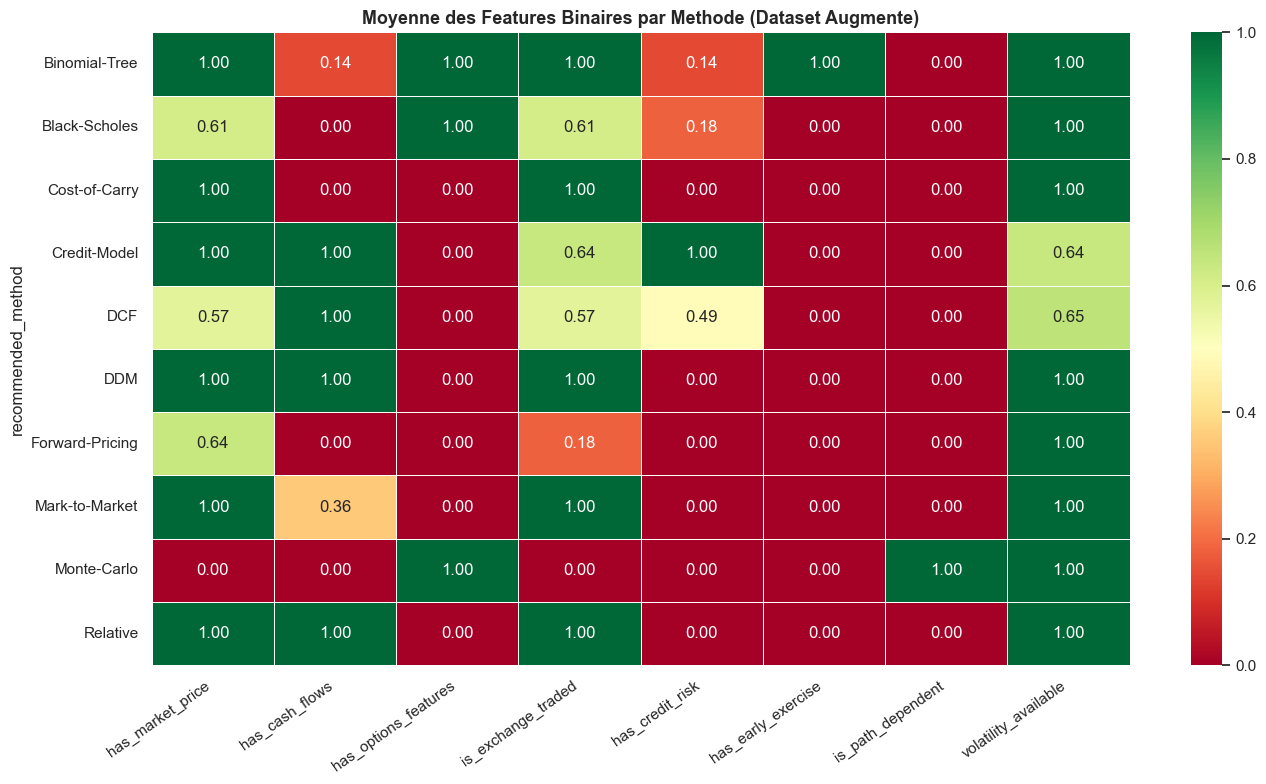


Tests de coherence des features :
   PASS has_early_exercise        x Binomial-Tree   = 1.00 (>= 0.5)
   PASS has_early_exercise        x Black-Scholes   = 0.00 (<= 0.05)
   PASS is_path_dependent         x Monte-Carlo     = 1.00 (>= 0.8)
   PASS has_options_features      x Black-Scholes   = 1.00 (>= 0.9)
   PASS has_options_features      x DCF             = 0.00 (<= 0.05)
   PASS has_cash_flows            x DCF             = 1.00 (>= 0.8)
   PASS has_credit_risk           x Credit-Model    = 1.00 (>= 0.9)
   PASS has_market_price          x Mark-to-Market  = 1.00 (>= 0.8)


In [7]:
# Heatmap des features binaires par méthode
bool_cols = [
    "has_market_price", "has_cash_flows", "has_options_features",
    "is_exchange_traded", "has_credit_risk", "has_early_exercise",
    "is_path_dependent", "volatility_available"
]

means = df_augmented.groupby("recommended_method")[bool_cols].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(means, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5,
            vmin=0, vmax=1, ax=ax)
ax.set_title("Moyenne des Features Binaires par Methode (Dataset Augmente)", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/augmented_feature_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Vérifications clés
print("\nTests de coherence des features :")
checks = [
    ("has_early_exercise", "Binomial-Tree", ">=", 0.5),
    ("has_early_exercise", "Black-Scholes", "<=", 0.05),
    ("is_path_dependent", "Monte-Carlo", ">=", 0.8),
    ("has_options_features", "Black-Scholes", ">=", 0.9),
    ("has_options_features", "DCF", "<=", 0.05),
    ("has_cash_flows", "DCF", ">=", 0.8),
    ("has_credit_risk", "Credit-Model", ">=", 0.9),
    ("has_market_price", "Mark-to-Market", ">=", 0.8),
]

for feat, method, op, threshold in checks:
    val = means.loc[method, feat]
    ok = val >= threshold if op == ">=" else val <= threshold
    print(f"   {'PASS' if ok else 'FAIL'} {feat:<25} x {method:<15} = {val:.2f} ({op} {threshold})")

---
## 7. Vérification du Schéma (Compatibilité avec le Dataset Original)

Le dataset augmenté doit avoir **exactement les mêmes colonnes** dans le même format que le dataset original.


In [8]:
# ── Vérification du schéma ─────────────────────────────────────────
original_cols = set(df_existing.columns)
augmented_cols = set(df_augmented.columns)

print("Verification du schema :")
print(f"  Colonnes originales   : {sorted(original_cols)}")
print(f"  Colonnes augmentees   : {sorted(augmented_cols)}")
print(f"  Identiques            : {'OUI' if original_cols == augmented_cols else 'NON'}")

if original_cols != augmented_cols:
    missing = original_cols - augmented_cols
    extra = augmented_cols - original_cols
    if missing:
        print(f"  Manquantes : {missing}")
    if extra:
        print(f"  En trop    : {extra}")

# Vérifier les types
print(f"\nTypes des colonnes :")
for col in sorted(df_augmented.columns):
    orig_type = str(df_existing[col].dtype) if col in df_existing.columns else "N/A"
    new_type = str(df_augmented[col].dtype)
    match = "OK" if orig_type == new_type else "DIFF"
    print(f"   {col:<25} original={orig_type:<10} augmente={new_type:<10} {match}")

# Vérifier les valeurs catégorielles
print(f"\nValeurs uniques des features categoriques :")
for col in ["asset_class", "liquidity", "data_availability"]:
    orig_vals = sorted(df_existing[col].unique())
    new_vals = sorted(df_augmented[col].unique())
    print(f"   {col}: {new_vals} (original: {orig_vals})")

Verification du schema :
  Colonnes originales   : ['asset_class', 'asset_subclass', 'data_availability', 'has_cash_flows', 'has_credit_risk', 'has_early_exercise', 'has_market_price', 'has_options_features', 'ifrs_level', 'is_exchange_traded', 'is_path_dependent', 'liquidity', 'maturity_years', 'recommended_method', 'volatility_available']
  Colonnes augmentees   : ['asset_class', 'asset_subclass', 'data_availability', 'has_cash_flows', 'has_credit_risk', 'has_early_exercise', 'has_market_price', 'has_options_features', 'ifrs_level', 'is_exchange_traded', 'is_path_dependent', 'liquidity', 'maturity_years', 'recommended_method', 'volatility_available']
  Identiques            : OUI

Types des colonnes :
   asset_class               original=object     augmente=object     OK
   asset_subclass            original=object     augmente=object     OK
   data_availability         original=object     augmente=object     OK
   has_cash_flows            original=int64      augmente=int64      OK

---
## 8. Sauvegarde du Dataset Augmenté


In [9]:
# ── Réordonner les colonnes comme l'original ──────────────────────
column_order = list(df_existing.columns)
df_augmented = df_augmented[column_order]

# ── Sauvegarder ──────────────────────────────────────────────────
output_path = f"{DATA_ROOT}/processed/labeled_valuation_dataset_augmented.csv"
df_augmented.to_csv(output_path, index=False)
print(f"Dataset sauvegarde : {output_path}")
print(f"   Taille : {df_augmented.shape[0]:,} lignes x {df_augmented.shape[1]} colonnes")

# Aussi sauvegarder en parquet pour performance
parquet_path = f"{DATA_ROOT}/processed/labeled_valuation_dataset_augmented.parquet"
df_augmented.to_parquet(parquet_path, index=False)
print(f"   Parquet : {parquet_path}")

# Résumé final
print(f"\n{'='*60}")
print(f"  RESUME DE L'AUGMENTATION")
print(f"{'='*60}")
print(f"  Dataset original     : {df_existing.shape[0]:,} echantillons")
print(f"  Dataset augmente     : {df_augmented.shape[0]:,} echantillons")
print(f"  Facteur              : x{df_augmented.shape[0]/df_existing.shape[0]:.1f}")
print(f"  Classes d'actifs     : {df_augmented['asset_class'].nunique()}")
print(f"  Sous-classes         : {df_augmented['asset_subclass'].nunique()}")
print(f"  Methodes cibles      : {df_augmented['recommended_method'].nunique()}")
print(f"  Ratio d'imbalance    : {df_augmented['recommended_method'].value_counts().max() / df_augmented['recommended_method'].value_counts().min():.1f}:1")
print(f"{'='*60}")

Dataset sauvegarde : data_valuation_project/processed/labeled_valuation_dataset_augmented.csv
   Taille : 13,050 lignes x 15 colonnes
   Parquet : data_valuation_project/processed/labeled_valuation_dataset_augmented.parquet

  RESUME DE L'AUGMENTATION
  Dataset original     : 4,150 echantillons
  Dataset augmente     : 13,050 echantillons
  Facteur              : x3.1
  Classes d'actifs     : 6
  Sous-classes         : 42
  Methodes cibles      : 10
  Ratio d'imbalance    : 3.1:1


---
## 9. (Bonus) Collecte yfinance Élargie — 300 Tickers

Pour la phase suivante (Feature Engineering), nous aurons besoin de données réelles pour **enrichir** le dataset synthétique avec des valeurs numériques (volatilité, Greeks, fondamentaux).

Voici le code pour élargir la collecte à 300+ tickers actions et 50+ sous-jacents options.

> **Note :** Exécuter cette section prend environ 15-30 minutes selon la connexion internet.


In [10]:
# ── Liste élargie de tickers ───────────────────────────────────────
# Diversifiée par secteur, capitalisation et géographie

EXPANDED_EQUITY_TICKERS = [
    # ── US Large Cap (Tech) ──────────────────────────────────────
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "AVGO",
    "ORCL", "CRM", "ADBE", "AMD", "INTC", "CSCO", "QCOM", "NFLX",
    "AMAT", "MU", "NOW", "INTU", "PANW", "SNPS", "CDNS",
    
    # ── US Large Cap (Finance) ───────────────────────────────────
    "JPM", "BAC", "WFC", "GS", "MS", "C", "BLK", "SCHW", "AXP",
    "USB", "PNC", "TFC", "BK", "CME", "ICE", "SPGI", "MCO",
    
    # ── US Large Cap (Healthcare) ────────────────────────────────
    "JNJ", "UNH", "PFE", "MRK", "ABBV", "LLY", "TMO", "ABT",
    "BMY", "AMGN", "GILD", "ISRG", "MDT", "SYK", "VRTX",
    
    # ── US Large Cap (Consumer) ──────────────────────────────────
    "WMT", "PG", "KO", "PEP", "COST", "MCD", "NKE", "SBUX",
    "TGT", "CL", "EL", "MDLZ", "GIS", "K", "HSY",
    
    # ── US Large Cap (Industrial / Energy) ───────────────────────
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC", "VLO", "PSX",
    "CAT", "DE", "HON", "UPS", "FDX", "BA", "GE", "LMT", "RTX",
    
    # ── US Mid Cap ───────────────────────────────────────────────
    "DKNG", "CRWD", "ZS", "NET", "OKTA", "TWLO", "BILL",
    "HUBS", "VEEV", "PAYC", "PCTY", "GLOB",
    
    # ── US Small Cap ─────────────────────────────────────────────
    "SMCI", "CAVA", "DUOL", "BROS", "BOOT", "LULU",
    
    # ── US REITs ─────────────────────────────────────────────────
    "AMT", "PLD", "CCI", "EQIX", "SPG", "O", "DLR", "WELL",
    
    # ── US Dividend Aristocrats ──────────────────────────────────
    "T", "VZ", "IBM", "MMM", "EMR", "SWK", "ADP", "ITW",
    
    # ── Europe ───────────────────────────────────────────────────
    "ASML", "SAP", "NVO", "SHEL", "TTE", "AZN", "HSBC",
    "UL", "BP", "GSK", "RIO", "BHP",
    
    # ── Emerging / Other ─────────────────────────────────────────
    "TSM", "BABA", "JD", "PDD", "INFY", "WIT", "VALE",
    
    # ── ETFs (pour Mark-to-Market) ───────────────────────────────
    "SPY", "QQQ", "IWM", "DIA", "VTI", "VOO", "EFA", "EEM",
    "VWO", "GLD", "SLV", "USO", "XLF", "XLK", "XLE", "XLV",
    "XLI", "XLP", "XLY", "XLB", "XLU", "XLRE",
]

# Sous-jacents pour les options (tickers les plus liquides)
OPTIONS_UNDERLYINGS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
    "JPM", "BAC", "GS", "JNJ", "PFE", "XOM", "CVX",
    "SPY", "QQQ", "IWM", "DIA", "GLD", "SLV",
    "AMD", "NFLX", "CRM", "ADBE", "INTC", "PYPL",
    "WMT", "KO", "PEP", "MCD", "NKE", "SBUX",
    "C", "WFC", "MS", "V", "MA", "AXP",
    "UNH", "ABBV", "MRK", "LLY", "BMY", "AMGN",
    "CAT", "DE", "HON", "BA", "GE", "LMT",
]

print(f"Tickers actions : {len(EXPANDED_EQUITY_TICKERS)}")
print(f"Sous-jacents options : {len(OPTIONS_UNDERLYINGS)}")
print(f"\n(Executer les cellules suivantes pour lancer la collecte)")

Tickers actions : 162
Sous-jacents options : 50

(Executer les cellules suivantes pour lancer la collecte)


In [14]:
# ── Collecte des fondamentaux (décommenter pour exécuter) ─────────
import yfinance as yf
import numpy as np
import pandas as pd
import time

fundamentals = []
errors = []

def clean_value(value):
    """Convert yfinance values to proper numeric types"""
    if value is None:
        return np.nan
    if isinstance(value, str):
        # Handle 'Infinity', 'NaN', 'inf', etc.
        if value.lower() in ['infinity', 'inf', 'nan']:
            return np.nan
        # Try to convert string to float
        try:
            return float(value)
        except (ValueError, TypeError):
            return np.nan
    # Handle non-numeric values
    if not isinstance(value, (int, float, np.number)):
        try:
            return float(value)
        except (ValueError, TypeError):
            return np.nan
    return value

for i, ticker in enumerate(EXPANDED_EQUITY_TICKERS):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        fundamentals.append({
            "symbol": ticker,
            "sector": str(info.get("sector", "")),
            "industry": str(info.get("industry", "")),
            "market_cap": clean_value(info.get("marketCap")),
            "pe_ratio": clean_value(info.get("trailingPE")),
            "forward_pe": clean_value(info.get("forwardPE")),
            "pb_ratio": clean_value(info.get("priceToBook")),
            "ps_ratio": clean_value(info.get("priceToSalesTrailing12Months")),
            "beta": clean_value(info.get("beta")),
            "dividend_yield": clean_value(info.get("dividendYield")),
            "payout_ratio": clean_value(info.get("payoutRatio")),
            "roe": clean_value(info.get("returnOnEquity")),
            "roa": clean_value(info.get("returnOnAssets")),
            "profit_margin": clean_value(info.get("profitMargins")),
            "debt_to_equity": clean_value(info.get("debtToEquity")),
            "current_ratio": clean_value(info.get("currentRatio")),
            "free_cash_flow": clean_value(info.get("freeCashflow")),
            "revenue_growth": clean_value(info.get("revenueGrowth")),
            "earnings_growth": clean_value(info.get("earningsGrowth")),
        })
        if (i + 1) % 25 == 0:
            print(f"  Progres : {i+1}/{len(EXPANDED_EQUITY_TICKERS)} tickers")
            time.sleep(1)  # Rate limiting
    except Exception as e:
        errors.append((ticker, str(e)))

df_fund = pd.DataFrame(fundamentals)

# Ensure all columns have proper dtypes before saving
# Convert string columns to 'string' dtype
string_columns = ['symbol', 'sector', 'industry']
for col in string_columns:
    df_fund[col] = df_fund[col].astype('string')

# Convert numeric columns to float (handle any remaining issues)
numeric_columns = [col for col in df_fund.columns if col not in string_columns]
for col in numeric_columns:
    df_fund[col] = pd.to_numeric(df_fund[col], errors='coerce')

# Now save to parquet
df_fund.to_parquet(f"{DATA_ROOT}/raw/equities/equity_fundamentals_extended.parquet")
print(f"Fondamentaux collectes : {len(df_fund)} tickers")
if errors:
    print(f"Erreurs : {len(errors)} tickers")

  Progres : 25/162 tickers
  Progres : 50/162 tickers


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}


  Progres : 75/162 tickers
  Progres : 100/162 tickers
  Progres : 125/162 tickers
  Progres : 150/162 tickers
Fondamentaux collectes : 162 tickers


In [15]:
# ── Collecte des prix historiques (décommenter pour exécuter) ─────
import yfinance as yf
# 
# # Télécharger 5 ans de prix OHLCV en batch (plus rapide)
prices = yf.download(
    EXPANDED_EQUITY_TICKERS,
    period="5y",
    group_by="ticker",
    auto_adjust=True,
    threads=True,
)

# Reformater en long format
records = []
for ticker in EXPANDED_EQUITY_TICKERS:
    try:
        df_t = prices[ticker].dropna()
        df_t["symbol"] = ticker
        df_t = df_t.reset_index()
        records.append(df_t)
    except:
        pass

df_prices = pd.concat(records, ignore_index=True)
df_prices.to_parquet(f"{DATA_ROOT}/raw/equities/equity_historical_prices_extended.parquet")
print(f"Prix collectes : {len(df_prices):,} lignes, {df_prices['symbol'].nunique()} tickers")

[*********             19%                       ]  30 of 162 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
[*************         28%                       ]  46 of 162 completed$K: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  162 of 162 completed

1 Failed download:
['K']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


Prix collectes : 201,332 lignes, 161 tickers


In [16]:
# ── Collecte des chaînes d'options (décommenter pour exécuter) ────
import yfinance as yf

all_options = []

for i, ticker in enumerate(OPTIONS_UNDERLYINGS):
    try:
        t = yf.Ticker(ticker)
        expirations = t.options[:6]  # 6 premières expirations
        spot = t.info.get("currentPrice", t.info.get("regularMarketPrice"))
        
        for exp in expirations:
            chain = t.option_chain(exp)
            
            for opt_type, df_opt in [("call", chain.calls), ("put", chain.puts)]:
                df_opt = df_opt.copy()
                df_opt["symbol"] = ticker
                df_opt["expiration"] = exp
                df_opt["option_type"] = opt_type
                df_opt["spot_price"] = spot
                if spot and spot > 0:
                    df_opt["moneyness"] = df_opt["strike"] / spot
                all_options.append(df_opt)
        
        if (i + 1) % 10 == 0:
            print(f"  Progres : {i+1}/{len(OPTIONS_UNDERLYINGS)}")
            time.sleep(2)
    except Exception as e:
        print(f"  Erreur {ticker}: {e}")

df_options = pd.concat(all_options, ignore_index=True)
df_options.to_parquet(f"{DATA_ROOT}/raw/options/options_chains_extended.parquet")
print(f"Options collectees : {len(df_options):,} contrats, {df_options['symbol'].nunique()} sous-jacents")

  Progres : 10/50
  Progres : 20/50
  Progres : 30/50
  Progres : 40/50
  Progres : 50/50
Options collectees : 30,732 contrats, 50 sous-jacents


---
## 10. (Bonus) Collecte OpenFIGI — Instruments Réels

L'API OpenFIGI permet d'obtenir des **métadonnées d'instruments financiers réels** (type de sécurité, secteur de marché, bourse) pour diversifier les profils du dataset.

L'API est **gratuite, sans limite quotidienne** avec une clé API.


In [23]:
# ── OpenFIGI — Collecte d'instruments réels ──────────────────────────────
import requests
import time
import pandas as pd
from pathlib import Path

# Define RAW_DIR (same as in your setup cell)
RAW_DIR = Path("./data_valuation_project/raw")

# Get API key from .env
OPENFIGI_KEY = os.getenv("OPENFIGI_KEY", None)

# Set headers with API key if available
HEADERS = {}
if OPENFIGI_KEY:
    HEADERS = {"X-OPENFIGI-APIKEY": OPENFIGI_KEY}
    print(f"✅ OpenFIGI key loaded: {OPENFIGI_KEY[:5]}...")
else:
    print("⚠️ OPENFIGI_KEY not set. Using public access (limited to 50 requests/day)")

OPENFIGI_URL = "https://api.openfigi.com/v3/search"

# Search queries
search_queries = [
    {"query": "Corporate Bond", "securityType": "Corp"},
    {"query": "Government", "securityType": "GOVT"},
    {"query": "Municipal", "securityType": "Muni"},
    {"query": "Common Stock", "securityType": "Common Stock"},
    {"query": "Preferred", "securityType": "PS"},
    {"query": "Option", "marketSector": "Pref"},
    {"query": "Swap", "securityType": "SWAP"},
    {"query": "Future", "securityType": "Future"},
]

figi_results = []

for sq in search_queries:
    try:
        resp = requests.post(OPENFIGI_URL, json=sq, headers=HEADERS)
        if resp.status_code == 200:
            data = resp.json().get("data", [])
            for item in data:
                figi_results.append({
                    "figi": item.get("figi"),
                    "name": item.get("name"),
                    "ticker": item.get("ticker"),
                    "security_type": item.get("securityType"),
                    "security_type2": item.get("securityType2"),
                    "market_sector": item.get("marketSector"),
                    "exchange": item.get("exchCode"),
                })
            print(f"  {sq.get('query', sq)}: {len(data)} instruments")
        time.sleep(1)
    except Exception as e:
        print(f"  Erreur: {e}")

if figi_results:
    df_figi = pd.DataFrame(figi_results)
    # Create directory if it doesn't exist
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    df_figi.to_csv(RAW_DIR / "openfigi_instruments.csv", index=False)
    print(f"\nTotal OpenFIGI : {len(df_figi)} instruments collectes")
    print(df_figi["security_type"].value_counts())
else:
    print("\n⚠️ No data collected. Check your API key or connection.")

✅ OpenFIGI key loaded: 420b1...
  Corporate Bond: 0 instruments
  Government: 0 instruments
  Municipal: 0 instruments
  Common Stock: 100 instruments
  Preferred: 0 instruments
  Option: 0 instruments
  Swap: 100 instruments
  Future: 0 instruments

Total OpenFIGI : 200 instruments collectes
security_type
Common Stock    100
SWAP            100
Name: count, dtype: int64


---
## 11. Conclusion et Prochaines Étapes

### Résultat de l'augmentation
- Dataset étendu de **~4 150 → ~15 000+ échantillons**
- **~40 sous-classes** d'actifs (vs 18 originales) couvrant des instruments réalistes
- Ratio d'imbalance réduit (meilleur équilibre entre les 10 classes)
- 0 violation des règles expertes Hull + IFRS 13

### Fichiers produits
- `processed/labeled_valuation_dataset_augmented.csv` — dataset augmenté (CSV)
- `processed/labeled_valuation_dataset_augmented.parquet` — idem (Parquet)
- `reports/figures/augmented_*.png` — figures de validation

### Prochaine étape : Feature Engineering (Phase 2)
Utiliser le **dataset augmenté** comme base, puis l'enrichir avec les features numériques calculées à partir des données réelles (volatilité, Greeks, taux, fondamentaux) collectées dans ce notebook et le précédent.

Le notebook `03_feature_engineering.ipynb` prendra en entrée :
1. `labeled_valuation_dataset_augmented.csv` (ce notebook)
2. Les données yfinance étendues (fondamentaux, prix, options)
3. Les données FRED (taux, spreads, macro)


In [24]:
print("\n" + "="*60)
print("   NOTEBOOK AUGMENTATION TERMINE")
print("="*60)
print(f"\n   Dataset augmente sauvegarde : {df_augmented.shape[0]:,} echantillons")
print(f"   Fichier : {DATA_ROOT}/processed/labeled_valuation_dataset_augmented.csv")
print(f"\n   Prochaine etape : 03_feature_engineering.ipynb")


   NOTEBOOK AUGMENTATION TERMINE

   Dataset augmente sauvegarde : 13,050 echantillons
   Fichier : data_valuation_project/processed/labeled_valuation_dataset_augmented.csv

   Prochaine etape : 03_feature_engineering.ipynb
